# Motivation

I would like to use this ML analysis for my thesis. <br>

My thesis is an interactive installation that invites visitors to allocate physical weights to containers hung from a loom to decide a weaving pattern for a textile. <br>
Each container is connected to a group of warps (vertical threds) through a pulley and strings, and the weights pulls down the strings, which pulls up the group of warps connected to the strings. <br>
Sicne weaving patterns are determined by which strings, vertical or horizontal are above, a group of warps allocated the weights become visible, while others don't. 

Through the installation, I want to explore, "How can humans value their decisioins grounded on their own thoughts and feelings when artificial intelligence can produce plausible answers?" <br>
I think a lot of "decision makings" are based on weights, both for humans and machines. Humans prioritize one thing from the others - in a sense, they weight their possible options. <br>
Machines, nowadays especially LLMs, produce text by guessing most likely word (token) that comes next, and each token chosen from the weighted candidates based on the large training dataset. <br>

As LLMs are increasingly integrated in our lives, I started to think at least my thoughts are influenced by LLMs to some extent, by limiting the information window I expose myself to, then thought if my mental weights (what I think something more important than others) are influenced or almost decided by LLMs and weights that are integrated in the LLM's function. 

In my installation, ideally I want to show the weights (= which vertical threds become visible) to weave "representative textile pattern from the history" at first and encourage visitors to add weights to reflect their own views to the weights that the model has, what we are made to see. 

Of course, there is no clear definition of "representative textile pattern from the history" and considering the limitation of data, collections, etc. nothing can meet this definition. <br>
But as a first step, I want to know which textiles are collected by a large museum, what are thought as important historical textile, by looking at the digital archive of the MET. <br>
I might not be able to use the analysis for an installation because of a lot of technical difficulties and the time frame, but I would like to try to work with museum's digital archive anyway and I hope it can create a ground for my future work after graduation. 

# MET Textile Image Classification

Fetching textile image data from the Metropolitan Museum of Art (MET) Open API and classifying them by culture.

## Overall Flow
1. **Data Collection**: Fetch textile metadata and images from the MET API
2. **Data Exploration**: Check how many items exist, what regions are available, etc.
3. **Pixelization**: Resize images to 16x16 and convert to pixel data.
4. **Image Classification**: Looking at the data, I will try to find interesting labels to classify them with SVC and RandomForest classifier.

## Step 0: Setup
Download 'data_utils.py' and 'image_utils.py' from the course repository since I thought it would make my life easier (thank you!), then import libraries.

https://metmuseum.github.io/

The MET API has patrameters 1, isHighlight, title, tags, detertmentId, isOnView, artistOrCulture, medium, hasImages, geoLocation, dateBegin, dateEnd.

There is "Textiles" in medium so I will use textile as a key. 

In [1]:
!wget -q https://github.com/PSAM-5020-2026S-A/5020-utils/raw/main/src/data_utils.py
!wget -q https://github.com/PSAM-5020-2026S-A/5020-utils/raw/main/src/image_utils.py

In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import requests
import time

from io import BytesIO
from PIL import Image as PImage
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from data_utils import classification_error, display_confusion_matrix
from image_utils import get_pixels

# Step 01: Search for the available data in API

In [3]:
BASE = "https://collectionapi.metmuseum.org/public/collection/v1"
session = requests.Session()

In [4]:
departments = session.get(f"{BASE}/departments", timeout=30).json()["departments"]
dept_df = pd.DataFrame(departments)
dept_df.head(10)

,departmentId,displayName
0,1,American Decorative Arts
1,3,Ancient West Asian Art
2,4,Arms and Armor
3,5,"Arts of Africa, Oceania, and the Americas"
4,6,Asian Art
5,7,The Cloisters
6,8,The Costume Institute
7,9,Drawings and Prints
8,10,Egyptian Art
9,11,European Paintings


In [5]:
def met_get(endpoint, params=None):
    url = BASE + endpoint
    response = session.get(url, params=params, timeout=30)
    response.raise_for_status()
    return response.json()

In [6]:
# Route A: Search by keywords
route_a = met_get("/search", params={
    "q": "textile",
    "hasImages": True
})

# Route A2: exclude "hasImages"
route_a2 = met_get("/search", params={
    "q": "textile"
})

# Route B: Use medium and hasImages 
route_b = met_get("/search", params={
    "q": "textile",
    "medium": "Textiles",
    "hasImages": True
})

# Route B2: exclude "hasImages"
route_b2 = met_get("/search", params={
    "q": "textile",
    "medium": "Textiles"
})

print("Route A total:", route_a["total"])
print("Route A2 total:", route_a2["total"])
print("Route B total:", route_b["total"])
print("Route B2 total:", route_b2["total"])

print("Route A first 10 IDs:", route_a.get("objectIDs", [])[:10])
print("Route A2 first 10 IDs:", route_a2.get("objectIDs", [])[:10])
print("Route B first 10 IDs:", route_b.get("objectIDs", [])[:10])
print("Route B2 first 10 IDs:", route_b2.get("objectIDs", [])[:10])

Route A total: 162
Route A2 total: 40659
Route B total: 32
Route B2 total: 33263
Route A first 10 IDs: [551786, 729644, 472562, 329077, 207249, 310453, 437422, 206965, 544740, 317877]
Route A2 first 10 IDs: [448602, 315786, 506174, 81136, 313153, 675980, 319474, 320054, 312615, 307991]
Route B first 10 IDs: [485416, 308024, 227160, 315700, 308022, 39742, 228990, 452315, 452188, 68310]
Route B2 first 10 IDs: [315786, 506174, 313153, 675980, 319474, 320054, 312615, 307991, 451100, 198116]


The MET archive doesn't have enough amount of textile archive with images? 
But when I searched in The MET collection https://www.metmuseum.org/art/collection/search?q=textile&showOnly=withImage&offset=0&material=Woven, I found 10,000+ results that are both "woven" and "has image".

I tried to include keywords other than textile below.

In [7]:
queries = ["textile", "woven", "silk", "tapestry", "embroidery", "fragment", "dress", "fabric"]

all_ids = set()

for q in queries:
    result = met_get("/search", params={
        "q": q,
        "hasImages": True
    })
    ids = result.get("objectIDs", []) or []
    all_ids.update(ids)
    print(q, result["total"])

print("unique IDs:", len(all_ids))

textile 162
woven 155
silk 183
tapestry 146
embroidery 138
fragment 164
dress 190
fabric 186
unique IDs: 274


The number of data is still small.
I thought there are many number of data that actually have images but somehow not "hasImage=True" 


In [8]:
queries = ["textile", "woven", "silk", "tapestry", "embroidery", "fragment", "dress", "fabric"]

all_ids = set()

for q in queries:
    result = met_get("/search", params={
        "q": q
    })
    ids = result.get("objectIDs", []) or []
    all_ids.update(ids)
    print(q, result["total"])

print("unique IDs:", len(all_ids))

textile 40659
woven 13518
silk 39447
tapestry 3707
embroidery 7345
fragment 40190
dress 14176
fabric 5267
unique IDs: 101716


In [9]:
def fetch_object(object_id):
    return met_get(f"/objects/{object_id}")

sample_id = route_b["objectIDs"][0]
sample_obj = fetch_object(sample_id)

print("sample objectID:", sample_id)
print("number of keys:", len(sample_obj))
print("first 30 keys:", list(sample_obj.keys())[:30])

sample_obj
sample_df = pd.DataFrame([sample_obj])
sample_df_position = pd.DataFrame.from_dict(sample_obj, orient="index", columns=["value"])
sample_df_position

sample objectID: 485416
number of keys: 57
first 30 keys: ['objectID', 'isHighlight', 'accessionNumber', 'accessionYear', 'isPublicDomain', 'primaryImage', 'primaryImageSmall', 'additionalImages', 'constituents', 'department', 'objectName', 'title', 'culture', 'period', 'dynasty', 'reign', 'portfolio', 'artistRole', 'artistPrefix', 'artistDisplayName', 'artistDisplayBio', 'artistSuffix', 'artistAlphaSort', 'artistNationality', 'artistBeginDate', 'artistEndDate', 'artistGender', 'artistWikidata_URL', 'artistULAN_URL', 'objectDate']


,value
objectID,485416
isHighlight,True
accessionNumber,1990.237a-c
accessionYear,1990
isPublicDomain,False
primaryImage,
primaryImageSmall,
additionalImages,[]
constituents,"[{'constituentID': 162312, 'role': 'Artist', '..."
department,Modern and Contemporary Art


I used a local Python to see how many data has at least either "primaryImage", "primaryImageSmall" or "additionalImages". 
I firstly tried with 300 data and got 222 out of 300 had image data!


## Step 2: See what kinds of data are in 5 objects that have iamges

In [20]:
import requests
from io import BytesIO
from IPython.display import display
import matplotlib.pyplot as plt
import requests
import PIL.Image as PImage

from io import BytesIO

from sklearn.cluster import KMeans

from image_utils import get_pixels, make_image

In [ ]:
# read csv
df_image = pd.read_csv("downloadable_images_textile".csv")
print(df_image.shape)
df_image.head()

(179, 11)


,objectID,title,department,objectName,classification,medium,isPublicDomain,best_image_url,primaryImage_exists,primaryImageSmall_exists,additionalImages_count
0,134,Architectural elements from a Retiring Room in...,The American Wing,Bedroom,NaN,Wood,True,https://images.metmuseum.org/CRDImages/ad/web-...,True,True,9
1,202,Spindle-back armchair,The American Wing,Armchair,NaN,"Maple, soft maple, ash",True,https://images.metmuseum.org/CRDImages/ad/web-...,True,True,3
2,225,Folding Armchair,The American Wing,Folding armchair,NaN,"Maple, steel mesh",True,https://images.metmuseum.org/CRDImages/ad/web-...,True,True,1
3,237,Armchair,The American Wing,Armchair,NaN,"Rosewood, prickly juniper veneer, gilding, bra...",True,https://images.metmuseum.org/CRDImages/ad/web-...,True,True,1
4,312668,Bag,The Michael C. Rockefeller Wing,Bag,Textiles-Woven,"Cotton, camelid hair",True,https://images.metmuseum.org/CRDImages/ao/web-...,True,True,1


In [26]:
first5 = df_image.head(5).copy()
first5[["objectID", "title", "best_image_url"]]

,objectID,title,best_image_url
0,134,Architectural elements from a Retiring Room in...,https://images.metmuseum.org/CRDImages/ad/web-...
1,202,Spindle-back armchair,https://images.metmuseum.org/CRDImages/ad/web-...
2,225,Folding Armchair,https://images.metmuseum.org/CRDImages/ad/web-...
3,237,Armchair,https://images.metmuseum.org/CRDImages/ad/web-...
4,312668,Bag,https://images.metmuseum.org/CRDImages/ao/web-...


In [27]:
sample_row = df_image.iloc[0]
sample_row

objectID                                                                  134
title                       Architectural elements from a Retiring Room in...
department                                                  The American Wing
objectName                                                            Bedroom
classification                                                            NaN
medium                                                                   Wood
isPublicDomain                                                           True
best_image_url              https://images.metmuseum.org/CRDImages/ad/web-...
primaryImage_exists                                                      True
primaryImageSmall_exists                                                 True
additionalImages_count                                                      9
Name: 0, dtype: object

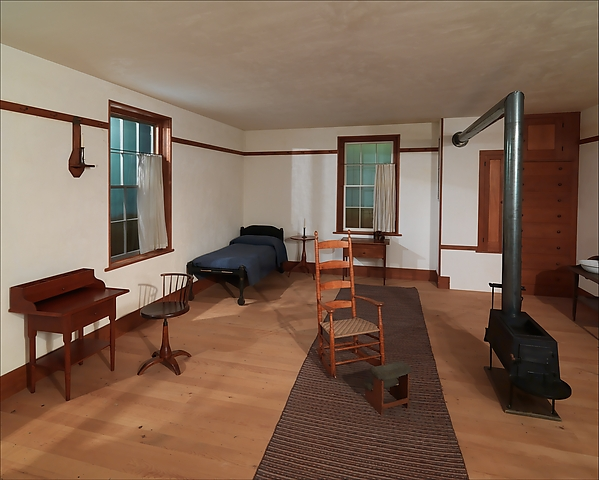

In [28]:
url = sample_row["best_image_url"]

response = requests.get(url, timeout =30)
img = PImage.open(BytesIO(response.content)).convert("RGB")
display(img)

I got something totally different ... I need to dig deeper to narrow down the category to just textiles. 

In [ ]:
image_width, image_hight = img.size
print(image_width, "x", image_hight)
print("total number of pixels:", image_width*image_hight)
print("bands:", img.getbands())

600 x 217
total number of pixels: 130200
bands: ('R', 'G', 'B')


I realized the image is mono-color and have lots of additional space around and it won't make sense to compare this with color pictures. <br>
So I wanted to know what kinds of characteristics the dataset has.

In [ ]:
pixels = get_pixels(img)
print("number of pixels:", len(pixels))
print("first 10 pixels:", pixels[:10])

number of pixels: 130200
first 10 pixels: [(213, 213, 213), (213, 213, 213), (213, 213, 213), (214, 214, 214), (214, 214, 214), (213, 213, 213), (213, 213, 213), (213, 213, 213), (211, 211, 211), (211, 211, 211)]


In [ ]:
def grayscale_ratio(img, tolerance=8):
    pixels = get_pixels(img)
    gray_count = 0

    for r, g, b in pixels:
        if abs(r-g) <= tolerance and abs(g-b) <= tolerance and abs(r-b) <= tolerance:
            gray_count += 1

    return gray_count / len(pixels)

In [ ]:
gray_ratio = grayscale_ratio(img)
print("grayscale ratio:", gray_ratio)

grayscale ratio: 1.0


In [ ]:
def blank_margin_ratio(img, brightness_threshold=235, tolerance=10):
    pixels = get_pixels(img)
    blank_count = 0

    for r, g, b in pixels:
        bright_enough = (r >= brightness_threshold and g >= brightness_threshold and b >= brightness_threshold)
        nearly_gray = (abs(r-g) <= tolerance and abs(g-b) <= tolerance and abs(r-b) <= tolerance)

        if bright_enough and nearly_gray:
            blank_count += 1

    return blank_count / len(pixels)

In [ ]:
margin_ratio = blank_margin_ratio(img)
print("blank margin ratio:", margin_ratio)

blank margin ratio: 0.015384024577572965


In [ ]:
def load_image_from_url(url):
    response = requests.get(url, timeout=30)
    return PImage.open(BytesIO(response.content)).convert("RGB")

In [ ]:
audit_rows = []

for _, row in df_image.iterrows():
    try:
        img = load_image_from_url(row["best_image_url"])

        audit_rows.append({
            "objectID": row["objectID"],
            "title": row["title"],
            "width": img.size[0],
            "height": img.size[1],
            "aspect_ratio": img.size[0] / img.size[1],
            "grayscale_ratio": grayscale_ratio(img),
            "blank_margin_ratio": blank_margin_ratio(img)
        })

    except Exception as e:
        print("skip:", row["objectID"], e)

In [ ]:
audit_df = pd.DataFrame(audit_rows)
audit_df.head()

,objectID,title,width,height,aspect_ratio,grayscale_ratio,blank_margin_ratio
0,448070,Textile Fragment,600,217,2.764977,1.000000,0.015384
1,437650,Madonna and Child,289,625,0.462400,0.313938,0.000000
2,786448,The Pleasures of Imagination,499,624,0.799679,0.092814,0.000003
3,291767,"[Smiling, Nude Baby Holding Foot, Seated on Fu...",599,400,1.497500,0.526519,0.000154
4,786452,"Costume of Hogs Norton, How a Man May Shoot Hi...",419,624,0.671474,0.020937,0.000004
